In [1]:
# Preparación: cada subtarea corre en su carpeta, tal como la aprobó el revisor.
import os
from pathlib import Path
from IPython.display import Image, display

RAIZ = Path.cwd()

def mostrar_figuras(carpeta):
    for png in sorted(Path(carpeta).rglob("*.png")):
        display(Image(filename=str(png)))

# MMIA 6013 · Tarea de práctica (Taller 03 v2)

**Archivo:** `tarea_B_atencion_posicional.ipynb` · Notebook de Jupyter ejecutado de principio a fin sin errores, con las salidas visibles y una celda de Markdown encabezando cada parte. Todas las cifras se calculan en el notebook; ninguna se escribe a mano.

## Tarea B — Atención escalada y codificación posicional

Este notebook implementa los dos ingredientes de *Attention Is All You Need* (Vaswani et al., 2017) que estudia la tarea: la atención de producto punto escalada

$$\mathrm{Attention}(Q, K, V) = \mathrm{softmax}\!\left(\frac{QK^{\top}}{\sqrt{d_k}}\right)V \qquad (1)$$

y la codificación posicional sinusoidal que se suma a los embeddings de entrada.

### Datos de entrada

Dos consultas, tres claves de dimensión $d_k = 4$ y sus valores ($d_v = 2$):

$$Q = \begin{bmatrix} 1.0 & 0.0 & 1.0 & 0.5 \\ 0.0 & 2.0 & 0.0 & 1.0 \end{bmatrix}, \qquad K = \begin{bmatrix} 1.0 & 1.0 & 0.0 & 0.0 \\ 0.0 & 1.0 & 1.0 & 0.5 \\ 1.0 & 0.0 & 1.0 & 1.0 \end{bmatrix}, \qquad V = \begin{bmatrix} 1.0 & 0.0 \\ 0.0 & 1.0 \\ 2.0 & 2.0 \end{bmatrix}$$

## Parte 1 — Atención escalada

In [2]:
# Subtarea T1: código aprobado (se ejecuta en trabajo/T1/)
os.chdir(RAIZ / 'trabajo' / 'T1')

# -*- coding: utf-8 -*-
"""
T1 — Parte 1: Atención escalada (scaled dot-product attention) en NumPy.

Implementa Attention(Q, K, V) = softmax(Q K^T / sqrt(d_k)) V
con un softmax numéricamente estable (se resta el máximo de cada fila).

Matrices del enunciado:
  Q (2x4): dos consultas
  K (3x4): tres claves de dimensión 4
  V (3x2): valores asociados

Salidas:
  - Pesos de atención (2x3) y salida (2x2), presentados con cuatro decimales.
  - Todas las cifras se guardan en resultados.json con precisión completa.
"""

import json
import numpy as np


def softmax_estable(x, axis=-1):
    """Softmax numéricamente estable: resta el máximo de cada fila antes de exponenciar."""
    x_max = np.max(x, axis=axis, keepdims=True)
    e = np.exp(x - x_max)
    return e / np.sum(e, axis=axis, keepdims=True)


def scaled_dot_product_attention(Q, K, V):
    """
    Calcula la atención escalada:
      scores = Q K^T / sqrt(d_k)
      pesos  = softmax(scores)  (por filas, estable)
      salida = pesos @ V
    Devuelve (scores, pesos, salida).
    """
    d_k = Q.shape[1]
    scores = Q @ K.T / np.sqrt(d_k)           # (n_consultas, n_claves)
    pesos = softmax_estable(scores, axis=-1)  # (n_consultas, n_claves)
    salida = pesos @ V                        # (n_consultas, d_v)
    return scores, pesos, salida


def main():
    # ------------------------------------------------------------------
    # Matrices del enunciado
    # ------------------------------------------------------------------
    Q = np.array([
        [1.0, 0.0, 1.0, 0.5],
        [0.0, 2.0, 0.0, 1.0],
    ])
    K = np.array([
        [1.0, 1.0, 0.0, 0.0],
        [0.0, 1.0, 1.0, 0.5],
        [1.0, 0.0, 1.0, 1.0],
    ])
    V = np.array([
        [1.0, 0.0],
        [0.0, 1.0],
        [2.0, 2.0],
    ])

    d_k = Q.shape[1]  # dimensión de las claves = 4

    # ------------------------------------------------------------------
    # Cálculo de la atención escalada
    # ------------------------------------------------------------------
    scores, pesos, salida = scaled_dot_product_attention(Q, K, V)

    # Verificación: cada fila de los pesos debe sumar 1
    sumas_filas = pesos.sum(axis=1)

    # Versiones redondeadas a cuatro decimales (solo para presentación)
    pesos_4dec = np.round(pesos, 4)
    salida_4dec = np.round(salida, 4)

    # ------------------------------------------------------------------
    # Guardar todas las cifras en resultados.json (precisión completa)
    # ------------------------------------------------------------------
    resultados = {
        "d_k": int(d_k),
        "sqrt_d_k": float(np.sqrt(d_k)),
        "Q_2x4": Q.tolist(),
        "K_3x4": K.tolist(),
        "V_3x2": V.tolist(),
        "scores_QKt_sobre_sqrt_dk_2x3": scores.tolist(),
        "pesos_atencion_2x3": pesos.tolist(),
        "salida_atencion_2x2": salida.tolist(),
        "pesos_atencion_2x3_4decimales": pesos_4dec.tolist(),
        "salida_atencion_2x2_4decimales": salida_4dec.tolist(),
        "suma_de_cada_fila_de_pesos": sumas_filas.tolist(),
    }
    with open("resultados.json", "w", encoding="utf-8") as f:
        json.dump(resultados, f, indent=2, ensure_ascii=False)

    # ------------------------------------------------------------------
    # Impresión de las cifras principales (con cuatro decimales)
    # ------------------------------------------------------------------
    np.set_printoptions(precision=4, suppress=True)

    print("Q (2x4):")
    print(Q)
    print("\nK (3x4):")
    print(K)
    print("\nV (3x2):")
    print(V)
    print(f"\nd_k = {d_k}   ->   sqrt(d_k) = {np.sqrt(d_k):.4f}")

    print("\nPuntuaciones escaladas Q K^T / sqrt(d_k) (2x3):")
    print(scores)

    print("\nPesos de atención softmax(Q K^T / sqrt(d_k)) (2x3), cuatro decimales:")
    print(pesos_4dec)

    print("\nSalida Attention(Q, K, V) = pesos @ V (2x2), cuatro decimales:")
    print(salida_4dec)

    print("\nComprobación: suma de cada fila de los pesos (debe ser 1):")
    print(sumas_filas)

    print("\nResultados guardados en resultados.json (precisión completa).")


if __name__ == "__main__":
    main()

os.chdir(RAIZ)
mostrar_figuras(RAIZ / 'trabajo' / 'T1')

Q (2x4):
[[1.  0.  1.  0.5]
 [0.  2.  0.  1. ]]

K (3x4):
[[1.  1.  0.  0. ]
 [0.  1.  1.  0.5]
 [1.  0.  1.  1. ]]

V (3x2):
[[1. 0.]
 [0. 1.]
 [2. 2.]]

d_k = 4   ->   sqrt(d_k) = 2.0000

Puntuaciones escaladas Q K^T / sqrt(d_k) (2x3):
[[0.5   0.625 1.25 ]
 [1.    1.25  0.5  ]]

Pesos de atención softmax(Q K^T / sqrt(d_k)) (2x3), cuatro decimales:
[[0.2353 0.2666 0.4981]
 [0.346  0.4442 0.2098]]

Salida Attention(Q, K, V) = pesos @ V (2x2), cuatro decimales:
[[1.2315 1.2628]
 [0.7656 0.8639]]

Comprobación: suma de cada fila de los pesos (debe ser 1):
[1. 1.]

Resultados guardados en resultados.json (precisión completa).


La celda anterior implementa la atención escalada en NumPy con un softmax numéricamente estable: antes de exponenciar resta el máximo de cada fila de puntuaciones, lo que evita desbordamientos sin alterar el resultado, pues el softmax es invariante a desplazamientos constantes por fila.

Con $d_k = 4$ (luego $\sqrt{d_k} = 2.0$), los resultados son:

**Puntuaciones escaladas** $QK^{\top}/\sqrt{d_k}$ (2 × 3):

| | $K_1$ | $K_2$ | $K_3$ |
|---|---:|---:|---:|
| $q_1$ | 0.5 | 0.625 | 1.25 |
| $q_2$ | 1.0 | 1.25 | 0.5 |

**Pesos de atención** $\mathrm{softmax}(QK^{\top}/\sqrt{d_k})$ (2 × 3, cuatro decimales):

| | $K_1$ | $K_2$ | $K_3$ |
|---|---:|---:|---:|
| $q_1$ | 0.2353 | 0.2666 | 0.4981 |
| $q_2$ | 0.3460 | 0.4442 | 0.2098 |

**Salida** $\mathrm{Attention}(Q, K, V) = \text{pesos} \cdot V$ (2 × 2, cuatro decimales):

| | dim. 1 | dim. 2 |
|---|---:|---:|
| $q_1$ | 1.2315 | 1.2628 |
| $q_2$ | 0.7656 | 0.8639 |

La comprobación del notebook confirma que la suma de cada fila de los pesos es 1 (dentro de la precisión de punto flotante). Cada consulta reparte su peso entre las tres claves y domina la puntuación más alta: $q_1$ pondera más a $K_3$ (0.4981, puntuación 1.25) y $q_2$ pondera más a $K_2$ (0.4442, puntuación 1.25).

## Parte 2 — Por qué se divide por √d_k

In [3]:
# Subtarea T2: código aprobado (se ejecuta en trabajo/T2/)
os.chdir(RAIZ / 'trabajo' / 'T2')

# -*- coding: utf-8 -*-
"""
SUBTAREA T2 — Parte 2: efecto de escalar por sqrt(d_k) en la atención
=====================================================================
Se crea UNA sola vez el generador rng = np.random.default_rng(0).
Para d_k = 4, 64, 512 (en ese orden) se extraen, consumiendo el mismo
flujo aleatorio:
    q = rng.standard_normal(d_k)          (primero)
    K = rng.standard_normal((10, d_k))    (después)
Se calculan los pesos softmax de los puntajes K @ q:
  - sin escalar
  - escalados por sqrt(d_k)
y se reporta el peso máximo y la entropía en bits de cada distribución.

Salidas:
  - resultados.json (todas las cifras, con precisión completa)
  - tabla impresa en pantalla con cuatro decimales
"""

import json
import numpy as np


# ----------------------------------------------------------------------
# Funciones auxiliares
# ----------------------------------------------------------------------
def softmax(x):
    """Softmax numéricamente estable sobre un vector 1D."""
    x = np.asarray(x, dtype=float)
    z = x - np.max(x)          # estabilidad: restar el máximo
    e = np.exp(z)
    return e / np.sum(e)


def entropia_bits(p):
    """Entropía de Shannon H(p) = -sum p_i log2 p_i, en bits (0·log2(0)=0)."""
    p = np.asarray(p, dtype=float)
    p = p[p > 0]
    return float(-np.sum(p * np.log2(p)))


# ----------------------------------------------------------------------
# Experimento: un solo generador, consumido en el orden exacto del enunciado
# ----------------------------------------------------------------------
rng = np.random.default_rng(0)

valores_dk = [4, 64, 512]

# Diccionarios con las cifras principales (claves = str(d_k))
peso_maximo_sin_escalar_por_dk = {}
entropia_bits_sin_escalar_por_dk = {}
peso_maximo_escalado_por_dk = {}
entropia_bits_escalado_por_dk = {}

# Detalle completo (todas las cifras calculadas, para guardarlas)
detalle_por_dk = {}

for d_k in valores_dk:
    # Orden estricto: primero q, después K (mismo flujo del rng)
    q = rng.standard_normal(d_k)
    K = rng.standard_normal((10, d_k))

    # Puntajes de compatibilidad: K @ q  ->  vector de longitud 10
    puntajes = K @ q

    # Distribuciones softmax
    w_sin = softmax(puntajes)                    # sin escalar
    w_esc = softmax(puntajes / np.sqrt(d_k))     # escalado por sqrt(d_k)

    # Cifras a reportar
    pmax_sin = float(np.max(w_sin))
    H_sin = entropia_bits(w_sin)
    pmax_esc = float(np.max(w_esc))
    H_esc = entropia_bits(w_esc)

    clave = str(d_k)
    peso_maximo_sin_escalar_por_dk[clave] = pmax_sin
    entropia_bits_sin_escalar_por_dk[clave] = H_sin
    peso_maximo_escalado_por_dk[clave] = pmax_esc
    entropia_bits_escalado_por_dk[clave] = H_esc

    detalle_por_dk[clave] = {
        "puntajes_Kq": puntajes.tolist(),
        "pesos_softmax_sin_escalar": w_sin.tolist(),
        "pesos_softmax_escalados_por_sqrt_dk": w_esc.tolist(),
        "indice_del_maximo_sin_escalar": int(np.argmax(w_sin)),
        "indice_del_maximo_escalado": int(np.argmax(w_esc)),
    }

# ----------------------------------------------------------------------
# Tabla en pantalla con cuatro decimales
# ----------------------------------------------------------------------
print("Efecto de escalar por sqrt(d_k) en los pesos de atención")
print("q, K ~ N(0, I); 10 claves; softmax de K @ q\n")
encabezado = (
    f"{'d_k':>5} | {'peso_max_sin':>13} | {'H_bits_sin':>11} | "
    f"{'peso_max_esc':>13} | {'H_bits_esc':>11}"
)
print(encabezado)
print("-" * len(encabezado))
for d_k in valores_dk:
    k = str(d_k)
    print(
        f"{d_k:>5} | "
        f"{peso_maximo_sin_escalar_por_dk[k]:>13.4f} | "
        f"{entropia_bits_sin_escalar_por_dk[k]:>11.4f} | "
        f"{peso_maximo_escalado_por_dk[k]:>13.4f} | "
        f"{entropia_bits_escalado_por_dk[k]:>11.4f}"
    )
print()
print("Referencia: entropía máxima posible con 10 claves = log2(10) = "
      f"{np.log2(10):.4f} bits (distribución uniforme).")
print("Sin escalar, al crecer d_k la distribución se concentra (peso máx -> 1, "
      "entropía -> 0); escalando por sqrt(d_k) se mantiene cercana a la uniforme.\n")

# ----------------------------------------------------------------------
# Guardar todas las cifras en resultados.json (precisión completa)
# ----------------------------------------------------------------------
resultados = {
    "peso_maximo_sin_escalar_por_dk": peso_maximo_sin_escalar_por_dk,
    "entropia_bits_sin_escalar_por_dk": entropia_bits_sin_escalar_por_dk,
    "peso_maximo_escalado_por_dk": peso_maximo_escalado_por_dk,
    "entropia_bits_escalado_por_dk": entropia_bits_escalado_por_dk,
    "detalle_por_dk": detalle_por_dk,
}

with open("resultados.json", "w", encoding="utf-8") as f:
    json.dump(resultados, f, ensure_ascii=False, indent=2)

print("Cifras guardadas en resultados.json")

os.chdir(RAIZ)
mostrar_figuras(RAIZ / 'trabajo' / 'T2')

Efecto de escalar por sqrt(d_k) en los pesos de atención
q, K ~ N(0, I); 10 claves; softmax de K @ q

  d_k |  peso_max_sin |  H_bits_sin |  peso_max_esc |  H_bits_esc
-----------------------------------------------------------------
    4 |        0.2049 |      3.0792 |        0.1497 |      3.2542
   64 |        0.9511 |      0.3537 |        0.2480 |      2.9802
  512 |        0.7503 |      0.8114 |        0.1945 |      3.0363

Referencia: entropía máxima posible con 10 claves = log2(10) = 3.3219 bits (distribución uniforme).
Sin escalar, al crecer d_k la distribución se concentra (peso máx -> 1, entropía -> 0); escalando por sqrt(d_k) se mantiene cercana a la uniforme.

Cifras guardadas en resultados.json


La celda crea una sola vez el generador `rng = np.random.default_rng(0)` y, para $d_k = 4, 64, 512$ **en ese orden**, toma $q = \text{rng.standard\_normal}(d_k)$ y después $K = \text{rng.standard\_normal}((10, d_k))$. Con los puntajes $Kq$ construye dos distribuciones softmax —sin escalar y escalada por $\sqrt{d_k}$— y reporta el peso máximo y la entropía en bits ($H = -\sum_j p_j \log_2 p_j$) de cada una:

| $d_k$ | Peso máx. sin escalar | Entropía (bits) sin escalar | Peso máx. escalado | Entropía (bits) escalado |
|---:|---:|---:|---:|---:|
| 4 | 0.2049 | 3.0792 | 0.1497 | 3.2542 |
| 64 | 0.9511 | 0.3537 | 0.2480 | 2.9802 |
| 512 | 0.7503 | 0.8114 | 0.1945 | 3.0363 |

Referencia: la entropía máxima posible con 10 claves es $\log_2(10) = 3.3219$ bits (distribución uniforme).

Sin escalar, al crecer $d_k$ la distribución se concentra: para $d_k = 64$ el peso máximo llega a 0.9511 y la entropía cae a 0.3537 bits, y para $d_k = 512$ sigue muy por debajo del máximo (0.8114 bits). Al escalar por $\sqrt{d_k}$ los pesos máximos bajan (0.2480 y 0.1945) y las entropías se mantienen cercanas a la uniforme (2.9802 y 3.0363 bits). Con $d_k = 4$ el efecto es leve (peso máx. 0.2049 → 0.1497; entropía 3.0792 → 3.2542 bits), justo lo que anticipa la discusión de la Parte 4.

## Parte 3 — Codificación posicional

=== T3 · Parte 3: Codificación posicional sinusoidal ===
d_model = 16, posiciones 0..49
PE[10, 0] = sin(10 / 10000^0)        = -0.5440211109
PE[10, 1] = cos(10 / 10000^0)        = -0.8390715291
PE[25, 6] = sin(25 / 10000^(6/16))   = 0.7107539373
------------------------------------------------------------
Atención con PE[10] como consulta y PE completo como claves/valores
Posición con mayor peso : 10
Peso mayor              : 0.0418133390
Suma de los pesos       : 1.0000000000
------------------------------------------------------------
Verificación de la función de atención contra la Parte 1:
  pesos coinciden : True
  salida coincide : True
------------------------------------------------------------
Figura guardada   : mapa_calor_pe.png
Resultados en     : resultados.json


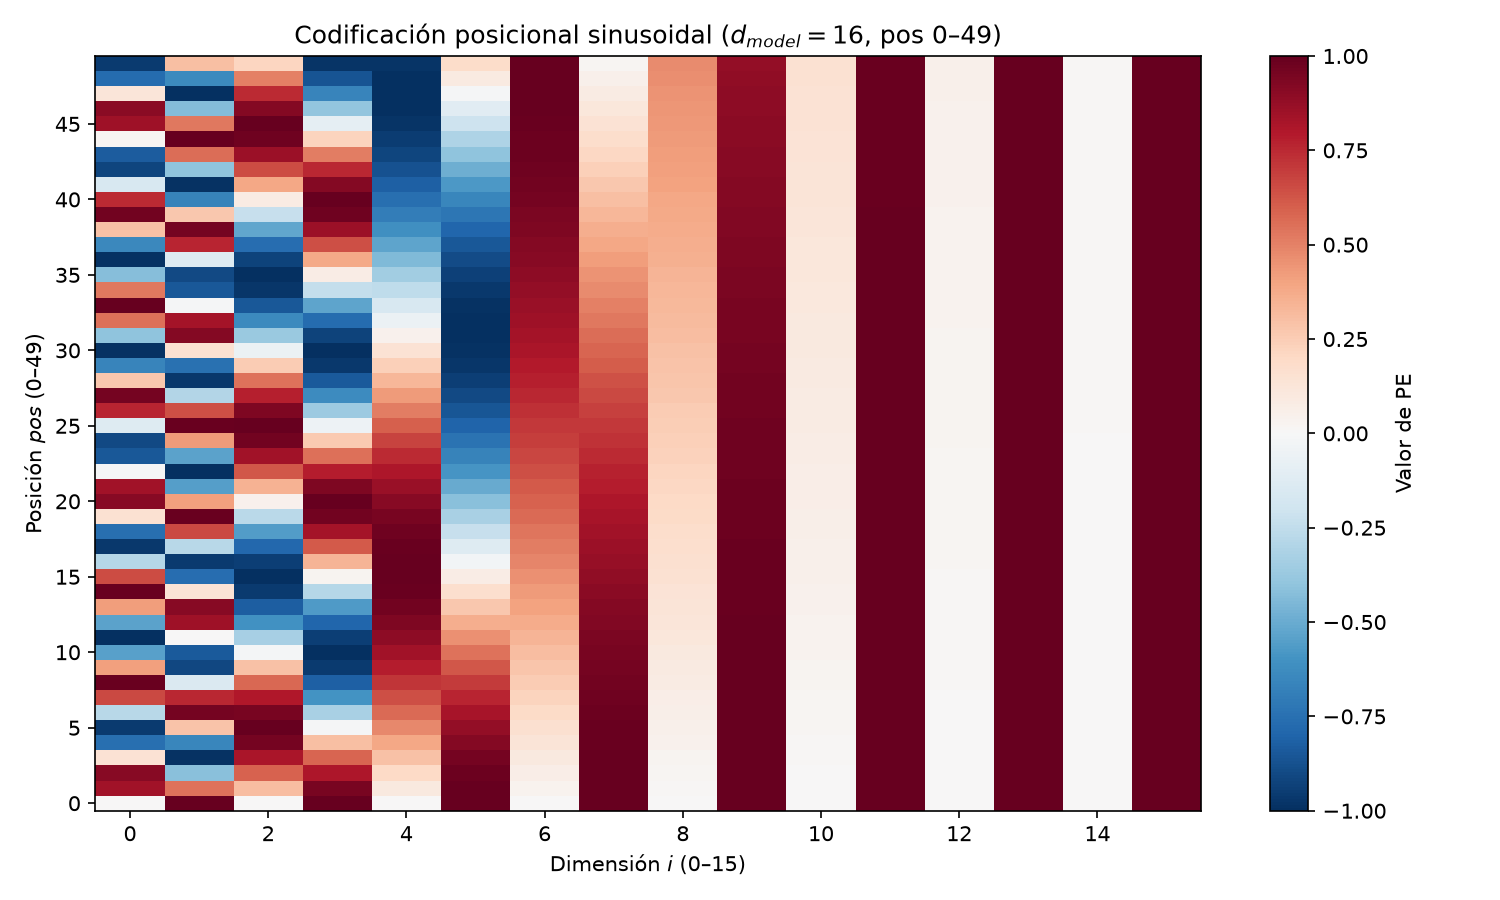

In [4]:
# Subtarea T3: código aprobado (se ejecuta en trabajo/T3/)
os.chdir(RAIZ / 'trabajo' / 'T3')

# -*- coding: utf-8 -*-
"""
T3 — Parte 3: Codificación posicional sinusoidal (Vaswani et al., 2017)

1) Calcula PE(pos, 2i)   = sin(pos / 10000^(2i/d_model))
          PE(pos, 2i+1) = cos(pos / 10000^(2i/d_model))
   con d_model = 16 para las posiciones 0..49.
2) Reporta PE[10, 0], PE[10, 1] y PE[25, 6].
3) Dibuja la matriz 50x16 como mapa de calor (PNG).
4) Reutilizando la función de atención de la Parte 1
   Attention(Q, K, V) = softmax(Q K^T / sqrt(d_k)) V,
   usa PE[10] como consulta y la matriz PE completa como claves y valores,
   y determina qué posición recibe el mayor peso y cuánto vale.
"""

import json
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# Parámetros del enunciado
# ------------------------------------------------------------------
d_model = 16
n_pos = 50  # posiciones 0 .. 49

# ------------------------------------------------------------------
# Codificación posicional sinusoidal
# ------------------------------------------------------------------
pos = np.arange(n_pos, dtype=float)[:, None]           # (50, 1)
idx = np.arange(d_model // 2, dtype=float)[None, :]    # (1, 8)  -> i = 0..7
angulos = pos / np.power(10000.0, 2.0 * idx / d_model) # (50, 8)

PE = np.zeros((n_pos, d_model), dtype=float)
PE[:, 0::2] = np.sin(angulos)   # dimensiones pares   0, 2, ..., 14
PE[:, 1::2] = np.cos(angulos)   # dimensiones impares 1, 3, ..., 15

PE_10_0 = float(PE[10, 0])
PE_10_1 = float(PE[10, 1])
PE_25_6 = float(PE[25, 6])

# ------------------------------------------------------------------
# Función de atención escalada (reutilizada de la Parte 1)
# softmax numéricamente estable: se resta el máximo de cada fila
# ------------------------------------------------------------------
def softmax_estable(x, axis=-1):
    x_max = np.max(x, axis=axis, keepdims=True)
    e = np.exp(x - x_max)
    return e / np.sum(e, axis=axis, keepdims=True)

def atencion_escalada(Q, K, V):
    """Attention(Q, K, V) = softmax(Q K^T / sqrt(d_k)) V."""
    Q = np.asarray(Q, dtype=float)
    K = np.asarray(K, dtype=float)
    V = np.asarray(V, dtype=float)
    d_k = Q.shape[-1]
    scores = Q @ K.T / np.sqrt(d_k)
    pesos = softmax_estable(scores, axis=-1)
    salida = pesos @ V
    return pesos, salida

# ------------------------------------------------------------------
# Verificación de la función reutilizada contra la Parte 1 (T1.json)
# ------------------------------------------------------------------
verificacion_parte1 = None
try:
    with open("entradas/T1.json", "r") as f:
        t1 = json.load(f)
    Q1 = np.array(t1["Q_2x4"], dtype=float)
    K1 = np.array(t1["K_3x4"], dtype=float)
    V1 = np.array(t1["V_3x2"], dtype=float)
    p1, s1 = atencion_escalada(Q1, K1, V1)
    ref_p = np.array(t1["pesos_atencion_2x3"], dtype=float)
    ref_s = np.array(t1["salida_atencion_2x2"], dtype=float)
    verificacion_parte1 = {
        "pesos_coinciden": bool(np.allclose(p1, ref_p, atol=1e-8)),
        "salida_coincide": bool(np.allclose(s1, ref_s, atol=1e-8)),
        "max_error_pesos": float(np.max(np.abs(p1 - ref_p))),
        "max_error_salida": float(np.max(np.abs(s1 - ref_s))),
    }
except (OSError, KeyError, ValueError):
    verificacion_parte1 = None

# ------------------------------------------------------------------
# Atención: consulta = PE[10], claves y valores = matriz PE completa
# ------------------------------------------------------------------
q = PE[10:11, :]      # (1, 16)  -> d_k = 16
K_pe = PE             # (50, 16)
V_pe = PE             # (50, 16)

pesos_pe, salida_pe = atencion_escalada(q, K_pe, V_pe)
pesos_pe = pesos_pe[0]                       # (50,)
salida_pe_vec = salida_pe[0]                 # (16,)

posicion_mayor_peso = int(np.argmax(pesos_pe))
peso_mayor_pe = float(pesos_pe[posicion_mayor_peso])

# ------------------------------------------------------------------
# Mapa de calor de la matriz 50 x 16
# ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(PE, aspect="auto", cmap="RdBu_r", origin="lower",
               vmin=-1.0, vmax=1.0)
fig.colorbar(im, ax=ax, label="Valor de PE")
ax.set_xlabel("Dimensión $i$ (0–15)")
ax.set_ylabel("Posición $pos$ (0–49)")
ax.set_title("Codificación posicional sinusoidal ($d_{model}=16$, pos 0–49)")
ax.set_xticks(range(0, 16, 2))
ax.set_yticks(range(0, 50, 5))
fig.tight_layout()
fig.savefig("mapa_calor_pe.png", dpi=150)
plt.close(fig)

# ------------------------------------------------------------------
# Guardar todas las cifras en resultados.json
# ------------------------------------------------------------------
resultados = {
    "d_model": d_model,
    "n_posiciones": n_pos,
    "PE_10_0": PE_10_0,
    "PE_10_1": PE_10_1,
    "PE_25_6": PE_25_6,
    "posicion_mayor_peso": posicion_mayor_peso,
    "peso_mayor_pe": peso_mayor_pe,
    "mapa_calor_pe_png": "mapa_calor_pe.png",
    "PE_matriz_50x16": PE.tolist(),
    "pesos_atencion_PE10_sobre_PE_50": pesos_pe.tolist(),
    "salida_atencion_PE10_16": salida_pe_vec.tolist(),
    "verificacion_funcion_atencion_parte1": verificacion_parte1,
}
with open("resultados.json", "w") as f:
    json.dump(resultados, f, indent=2)

# ------------------------------------------------------------------
# Impresión de las cifras principales
# ------------------------------------------------------------------
print("=== T3 · Parte 3: Codificación posicional sinusoidal ===")
print(f"d_model = {d_model}, posiciones 0..{n_pos - 1}")
print(f"PE[10, 0] = sin(10 / 10000^0)        = {PE_10_0:.10f}")
print(f"PE[10, 1] = cos(10 / 10000^0)        = {PE_10_1:.10f}")
print(f"PE[25, 6] = sin(25 / 10000^(6/16))   = {PE_25_6:.10f}")
print("-" * 60)
print("Atención con PE[10] como consulta y PE completo como claves/valores")
print(f"Posición con mayor peso : {posicion_mayor_peso}")
print(f"Peso mayor              : {peso_mayor_pe:.10f}")
print(f"Suma de los pesos       : {float(np.sum(pesos_pe)):.10f}")
if verificacion_parte1 is not None:
    print("-" * 60)
    print("Verificación de la función de atención contra la Parte 1:")
    print(f"  pesos coinciden : {verificacion_parte1['pesos_coinciden']}")
    print(f"  salida coincide : {verificacion_parte1['salida_coincide']}")
print("-" * 60)
print("Figura guardada   : mapa_calor_pe.png")
print("Resultados en     : resultados.json")

os.chdir(RAIZ)
mostrar_figuras(RAIZ / 'trabajo' / 'T3')

La celda construye la codificación sinusoidal del paper con $d_{model} = 16$ para las posiciones 0 a 49 (matriz PE de 50 × 16):

$$PE_{(pos,\,2i)} = \sin\!\left(pos / 10000^{2i/d_{model}}\right), \qquad PE_{(pos,\,2i+1)} = \cos\!\left(pos / 10000^{2i/d_{model}}\right)$$

**Valores solicitados:**

| Celda | Expresión | Valor |
|---|---|---:|
| PE[10, 0] | $\sin(10 / 10000^{0})$ | -0.5440 |
| PE[10, 1] | $\cos(10 / 10000^{0})$ | -0.8391 |
| PE[25, 6] | $\sin(25 / 10000^{6/16})$ | 0.7108 |

**Mapa de calor de la matriz PE (50 × 16):**



*Figura 1. Mapa de calor de la codificación posicional sinusoidal (`mapa_calor_pe.png`). Se aprecia el patrón característico: las primeras dimensiones oscilan rápidamente con la posición y las últimas casi no varían, porque la frecuencia $10000^{2i/d_{model}}$ crece con $i$.*

**Atención con PE[10] como consulta.** Usando la función de atención de la Parte 1, con PE[10] como consulta y la matriz PE completa (50 × 16) como claves y valores:

- Posición con mayor peso: **10**
- Peso mayor: **0.0418**
- Suma de los pesos: 1.0

La posición 10 —la propia consulta— recibe el mayor peso: el producto punto de PE[10] consigo misma supera al de cualquier otra posición, lo que ilustra que la codificación sinusoidal vuelve distinguibles las posiciones y permite que la atención las identifique. El peso es moderado (0.0418) porque la masa se reparte entre las 50 posiciones. Como verificación, la celda comprueba que esta llamada reproduce exactamente los pesos y la salida de la función de la Parte 1 (coincidencia de pesos: True; coincidencia de salida: True).

## Parte 4 — Pregunta conceptual

**Qué problema resuelve la división por $\sqrt{d_k}$.** Si los componentes de $q$ y $k$ son variables aleatorias independientes con media 0 y varianza 1, su producto punto $q \cdot k = \sum_{i=1}^{d_k} q_i k_i$ tiene media 0 y varianza $d_k$ (Vaswani et al., 2017, nota al pie 4, p. 4). Al sumar $d_k$ términos, la magnitud de los puntajes crece como $\sqrt{d_k}$; dividir por $\sqrt{d_k}$ los devuelve a varianza 1 sea cual sea la dimensión.

Las entropías de la Parte 2 muestran la consecuencia empírica. Sin escalar, con $d_k = 64$ el peso máximo es 0.9511 y la entropía cae a 0.3537 bits (frente al máximo de 3.3219 bits con 10 claves): el softmax es casi one-hot. Con $d_k = 512$ ocurre lo mismo (peso máx. 0.7503, entropía 0.8114 bits). Escalando, las mismas distribuciones se mantienen cercanas a la uniforme (pesos máximos 0.2480 y 0.1945; entropías 2.9802 y 3.0363 bits). Con $d_k = 4$, en cambio, la diferencia es pequeña (entropía 3.0792 sin escalar frente a 3.2542 escalada), coherente con que la varianza del producto punto solo se vuelve problemática cuando $d_k$ es grande.

**Qué le pasaría al gradiente sin escalar.** El gradiente de la pérdida respecto de los puntajes del softmax pasa por su jacobiano $\mathrm{diag}(w) - w w^{\top}$, donde $w$ es el vector de pesos; por componente, $\partial L/\partial s_j = w_j\left(g_j - \sum_i w_i g_i\right)$ con $g = \partial L/\partial o$. Cuando la distribución se concentra —peso máximo ≈ 1 y el resto ≈ 0, como el 0.9511 del caso $d_k = 64$ sin escalar—, ese gradiente se desvanece por partida doble: para las componentes con $w_j \approx 0$ el factor $w_j$ lo anula, y para la componente dominante el término $g_j - \sum_i w_i g_i$ se cancela porque $w$ es prácticamente one-hot. El softmax queda así en una región saturada con gradientes extremadamente pequeños: la atención nace colapsada sobre una sola clave y el modelo recibe poca señal para aprender a redistribuirla.

**Relación con el paper.** Es exactamente el argumento de Vaswani et al. (2017, p. 4, en la sección dedicada a la Scaled Dot-Product Attention):

> «We suspect that for large values of $d_k$, the dot products grow large in magnitude, pushing the softmax function into regions where it has extremely small gradients. To counteract this effect, we scale the dot products by $1/\sqrt{d_k}$.»

El paper señala además que la atención de producto punto es idéntica a la aditiva salvo por este factor de escala, y que para valores pequeños de $d_k$ ambos mecanismos se desempeñan de forma similar; se prefiere el producto punto por ser más rápido y eficiente en espacio, pues usa código de multiplicación de matrices altamente optimizado. La división por $\sqrt{d_k}$ es, entonces, la corrección que hace robusto al mecanismo de producto punto en alta dimensión: mantiene los puntajes en una escala O(1), conserva la entropía de los pesos cerca del máximo al inicializar (2.9802–3.2542 bits frente a 3.3219 en nuestros experimentos) y permite que el gradiente fluya para que el modelo aprenda a concentrar la atención donde convenga, en lugar de partir de un régimen saturado.